In [63]:
import numpy as np
import pandas as pd


In [64]:
# Compute daily returns for all funds
nav=pd.read_csv("../data/processed/clean_nav.csv")


In [65]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [66]:
nav.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [67]:
nav["date"]=pd.to_datetime(nav["date"])

In [68]:
nav["daily_returns"]=(nav.groupby("amfi_code")["nav"].pct_change())

In [69]:
nav.head()

,amfi_code,date,nav,daily_returns
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [70]:
nav.to_csv("processed/returns_computed.csv",index=False)


In [71]:
print("Daily returns calculated successfully!")

Daily returns calculated successfully!


In [72]:
# Calculate CAGR for 1yr, 3yr, 5yr periods.

nav2= pd.read_csv("processed/returns_computed.csv")
nav2

,amfi_code,date,nav,daily_returns
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106
45996,149324,2026-05-26,291.2707,-0.004138
45997,149324,2026-05-27,288.8007,-0.008480
45998,149324,2026-05-28,280.6873,-0.028093


In [73]:
nav2.dtypes

amfi_code          int64
date              object
nav              float64
daily_returns    float64
dtype: object

In [74]:
nav2["date"]=pd.to_datetime(nav2["date"])

In [75]:
nav2.dtypes


amfi_code                 int64
date             datetime64[ns]
nav                     float64
daily_returns           float64
dtype: object

In [76]:
nav2=nav2.sort_values(["amfi_code", "date"]) #sort the data

In [77]:
groups = nav2.groupby("amfi_code") # group by one fund at a time
results = []
for amfi_code, group in groups:
    group = group.sort_values("date")
    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]
    years = (group["date"].iloc[-1] - group["date"].iloc[0]).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    results.append({"amfi_code": amfi_code,"CAGR": cagr})

In [78]:
cagr_df = pd.DataFrame(results)
cagr_df.to_csv("processed/cagr_report.csv",index=False)
print(cagr_df.head())

   amfi_code      CAGR
0     100016  0.026371
1     100025  0.044582
2     100033  0.301232
3     101206  0.235384
4     101207  0.079388


In [79]:
cagr_df.shape

(40, 2)

In [80]:
#3. Compute Sharpe Ratio:

nav3 =pd.read_csv("processed/returns_computed.csv")


In [81]:
rf_annual = 0.065
rf_daily = rf_annual / 252

In [82]:
groups = nav3.groupby("amfi_code")

In [83]:
# Calculate the Sharpe Ratio
results = []
for amfi_code, group in groups:
    returns = group["daily_returns"].dropna()
    mean_return = returns.mean()
    std_return = returns.std()
    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = ((mean_return - rf_daily) / std_return) * np.sqrt(252)
    results.append({"amfi_code": amfi_code,"Sharpe_Ratio": sharpe})

In [84]:
sharpe_df = pd.DataFrame(results) #Create a DataFrame

In [85]:
sharpe_df["Rank"]=sharpe_df["Sharpe_Ratio"].rank(ascending=False,method="dense") # Rank the funds


In [86]:
sharpe_df.to_csv("processed/sharpe_values.csv",index=False)
print(sharpe_df.head())

   amfi_code  Sharpe_Ratio  Rank
0     100016     -0.201517  35.0
1     100025     -0.567095  39.0
2     100033      1.093699   7.0
3     101206      1.027213   9.0
4     101207      0.162661  28.0


In [87]:
# Day 4 – Task 4: Compute Sortino Ratio

nav4 =pd.read_csv("processed/returns_computed.csv")

In [88]:
rf_annual=0.065
rf_daily=rf_annual/252

In [89]:
groups = nav4.groupby("amfi_code") #Group by fund
len(groups)

40

In [90]:
# Calculate Sortino Ratio
results = [] #Create an empty list:
for amfi_code, group in groups:
    returns = group["daily_returns"].dropna()
    mean_return = returns.mean()
    downside_returns = returns[returns < 0] #keeps only the days where the return is negative.Only these are used to calculate risk
    downside_std = downside_returns.std()
    # Compute the ratio 
    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - rf_daily) / downside_std) * np.sqrt(252)
    results.append({"amfi_code": amfi_code,"Sortino_Ratio": sortino}) #Store the result:

In [91]:
sortino_df = pd.DataFrame(results)

In [92]:
# Rank the funds
sortino_df["Rank"] = sortino_df["Sortino_Ratio"].rank(ascending=False,method="dense")

In [93]:
sortino_df.to_csv("processed/sortino_values.csv",index=False)
print(sortino_df.head())

   amfi_code  Sortino_Ratio  Rank
0     100016      -0.351047  36.0
1     100025      -0.941821  39.0
2     100033       1.829134   8.0
3     101206       1.799563  10.0
4     101207       0.276644  28.0


In [94]:
# part 5 :Compute Alpha & Beta vs benchmark

from scipy.stats import linregress      # The task specifies by using this

In [95]:
fund = pd.read_csv("processed/returns_computed.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [96]:
benchmark.columns
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [97]:
nifty100 = benchmark[benchmark["index_name"]=="NIFTY100"].copy()


In [98]:
fund.dtypes
nifty100.dtypes

date            object
index_name      object
close_value    float64
dtype: object

In [99]:
fund["date"]=pd.to_datetime(fund["date"])
nifty100["date"]=pd.to_datetime(nifty100["date"])

In [100]:
#Compute benchmark daily returns
nifty100 = nifty100.sort_values("date") #sort data
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [101]:
# Merge fund and benchmark
merged=pd.merge(fund,nifty100[["date","benchmark_return"]],on="date",how="inner")
merged.head()

,amfi_code,date,nav,daily_returns,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [102]:
# Group by fund
groups = merged.groupby("amfi_code")

In [103]:
# linear regression
results = []
for amfi_code, group in groups:
    group = group.dropna()
    slope, intercept, r_value, p_value, std_err = linregress(group["benchmark_return"],group["daily_returns"])
    alpha = intercept * 252
    beta = slope
    results.append({"amfi_code": amfi_code,"Alpha": alpha,"Beta": beta})
alpha_beta = pd.DataFrame(results) #Create DataFrame

In [104]:
alpha_beta["Alpha_Rank"]=alpha_beta["Alpha"].rank(ascending=False,method="dense") #Rank by Alpha

In [105]:
alpha_beta.to_csv("processed/alpha_beta.csv",index=False)
alpha_beta.head()

,amfi_code,Alpha,Beta,Alpha_Rank
0,100016,0.037476,-0.058268,39.0
1,100025,0.042818,0.001158,38.0
2,100033,0.271954,0.005104,6.0
3,101206,0.213998,0.021086,12.0
4,101207,0.108971,-0.065289,27.0


In [106]:
# task 6- compute maximum drawdown

nav6 =pd.read_csv("../Day3_EDA/02_nav_history.csv")
nav6.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [107]:
nav6["date"]=pd.to_datetime(nav6["date"])

In [108]:
nav6=nav6.sort_values(["amfi_code","date"])

In [109]:
results = [] #Create an empty list
for amfi_code, group in groups:
    group["running_max"] = group["nav"].cummax() #Running maximum NAV.cummax()=cummalative maximum
    group["drawdown"] = group["nav"] / group["running_max"] - 1 #Calculate drawdown
    max_dd = group["drawdown"].min() #Finding Maximum Drawdown
    worst_date = group.loc[group["drawdown"].idxmin(), "date"] #Finding the date of the worst drawdown
    results.append({"amfi_code": amfi_code,"Maximum_Drawdown": max_dd,"Worst_Drawdown_Date": worst_date}) #Store the result

In [110]:
drawdown_df = pd.DataFrame(results)#Creating the DataFrame

In [111]:
drawdown_df["Rank"] = drawdown_df["Maximum_Drawdown"].rank(ascending=False,method="dense") #Rank the funds

In [112]:
drawdown_df.to_csv("processed/max_drawdown.csv", index=False) #Saving the results

In [113]:
#Task 7 - Build Fund Scorecard

scorecard = cagr_df.copy()


In [114]:
scorecard = scorecard.merge(sharpe_df[["amfi_code", "Sharpe_Ratio"]],on="amfi_code",how="inner") # Add Sharpe

In [115]:
scorecard = scorecard.merge(alpha_beta[["amfi_code", "Alpha"]],on="amfi_code",how="inner") #Add Alpha

In [116]:
scorecard = scorecard.merge(drawdown_df[["amfi_code", "Maximum_Drawdown"]],on="amfi_code",how="inner") #Add Maximum Drawdown

In [117]:
# Needed expense_ratio_pct,so wee need to load scheme performance file
scheme_performance = pd.read_csv("../data/processed/clean_performance.csv")

In [118]:
scheme_performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'negative_sharpe'],
      dtype='object')

In [119]:
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,negative_sharpe
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [120]:
scheme_performance.shape

(40, 20)

In [121]:
# Add expense ratio to your scorecard
scorecard = scorecard.merge(scheme_performance[["amfi_code", "expense_ratio_pct"]],on="amfi_code",how="inner")

In [122]:
scorecard.columns

Index(['amfi_code', 'CAGR', 'Sharpe_Ratio', 'Alpha', 'Maximum_Drawdown',
       'expense_ratio_pct'],
      dtype='object')

In [123]:
scorecard.shape

(40, 6)

In [125]:
scorecard.head()

,amfi_code,CAGR,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct
0,100016,0.026371,-0.201517,0.037476,-0.247344,1.55
1,100025,0.044582,-0.567095,0.042818,-0.043083,0.56
2,100033,0.301232,1.093699,0.271954,-0.162172,1.38
3,101206,0.235384,1.027213,0.213998,-0.112916,1.60
4,101207,0.079388,0.162661,0.108971,-0.354469,1.53


In [126]:
# Rank each performance metric
scorecard["CAGR_Rank"] = scorecard["CAGR"].rank(ascending=False,method="min")

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False,method="min")

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False,method="min")

# Lower expense ratio is better
scorecard["Expense_Ratio_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True,method="min")

# Less negative / higher maximum drawdown is better
scorecard["Max_DD_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False,method="min")

In [127]:
# Convert ranks into scores
n = len(scorecard)
scorecard["CAGR_Score"] = (n - scorecard["CAGR_Rank"]) / (n - 1) * 100
scorecard["Sharpe_Score"] = (n - scorecard["Sharpe_Rank"]) / (n - 1) * 100
scorecard["Alpha_Score"] = (n - scorecard["Alpha_Rank"]) / (n - 1) * 100
scorecard["Expense_Score"] = (n - scorecard["Expense_Ratio_Rank"]) / (n - 1) * 100
scorecard["Max_DD_Score"] = (n - scorecard["Max_DD_Rank"]) / (n - 1) * 100

In [128]:
# Calculate final score
scorecard["Final_Score"] = (
    0.30 * scorecard["CAGR_Score"] +
    0.25 * scorecard["Sharpe_Score"] +
    0.20 * scorecard["Alpha_Score"] +
    0.15 * scorecard["Expense_Score"] +
    0.10 * scorecard["Max_DD_Score"])

In [129]:
# Rank the funds
scorecard["Final_Rank"] = scorecard["Final_Score"].rank(ascending=False,method="min")
scorecard = scorecard.sort_values("Final_Score", ascending=False)

In [131]:
scorecard.to_csv("processed/fund_scorecard.csv",index=False)

In [ ]:
# Task 8 — Benchmark Comparison Chart + Tracking Error

top5 = scorecard.head(5)
print(top5[["amfi_code", "Final_Score", "Final_Rank"]])

,amfi_code,Final_Score,Final_Rank
25,120505,84.871795,1.0
34,148567,83.589744,2.0
30,120843,82.307692,3.0
2,100033,78.333333,4.0
36,148569,76.282051,5.0


In [139]:
# Get their AMFI codes
top5_codes = top5["amfi_code"].tolist()
top5_codes

[120505, 148567, 120843, 100033, 148569]

In [144]:
# Load the NAV data
top5_nav = nav2[nav2["amfi_code"].isin(top5_codes)].copy()

In [147]:
top5_nav.shape
top5_nav["amfi_code"].nunique()

5

In [150]:
# Keep only the last 3 years
latest_date = top5_nav["date"].max()
latest_date

Timestamp('2026-05-29 00:00:00')

In [149]:
# Then calculate the 3-year starting date
start_date = latest_date - pd.DateOffset(years=3)
start_date

Timestamp('2023-05-29 00:00:00')

In [ ]:
# Load the benchmark data
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [152]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [154]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

In [ ]:
# Filter benchmarks to 3 years
nifty50 = nifty50[(nifty50["date"] >= start_date) &(nifty50["date"] <= latest_date)].copy()
nifty100 = nifty100[(nifty100["date"] >= start_date) &(nifty100["date"] <= latest_date)].copy()

In [156]:
# Calculate benchmark daily returns
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")
nifty50["return"] = nifty50["close_value"].pct_change()
nifty100["return"] = nifty100["close_value"].pct_change()

In [157]:
# Calculate cumulative returns for the chart
fund_chart = top5_nav.copy()
fund_chart["normalized"] = (fund_chart.groupby("amfi_code")["nav"].transform(lambda x: x / x.iloc[0] * 100))

In [158]:
fund_chart = top5_nav.copy()
fund_chart["normalized"] = (fund_chart.groupby("amfi_code")["nav"].transform(lambda x: x / x.iloc[0] * 100))

In [159]:
# For Nifty 50
nifty50["normalized"] = (nifty50["close_value"] /nifty50["close_value"].iloc[0] * 100)

In [160]:
# For Nifty 100:
nifty100["normalized"] = (nifty100["close_value"] /nifty100["close_value"].iloc[0] * 100)

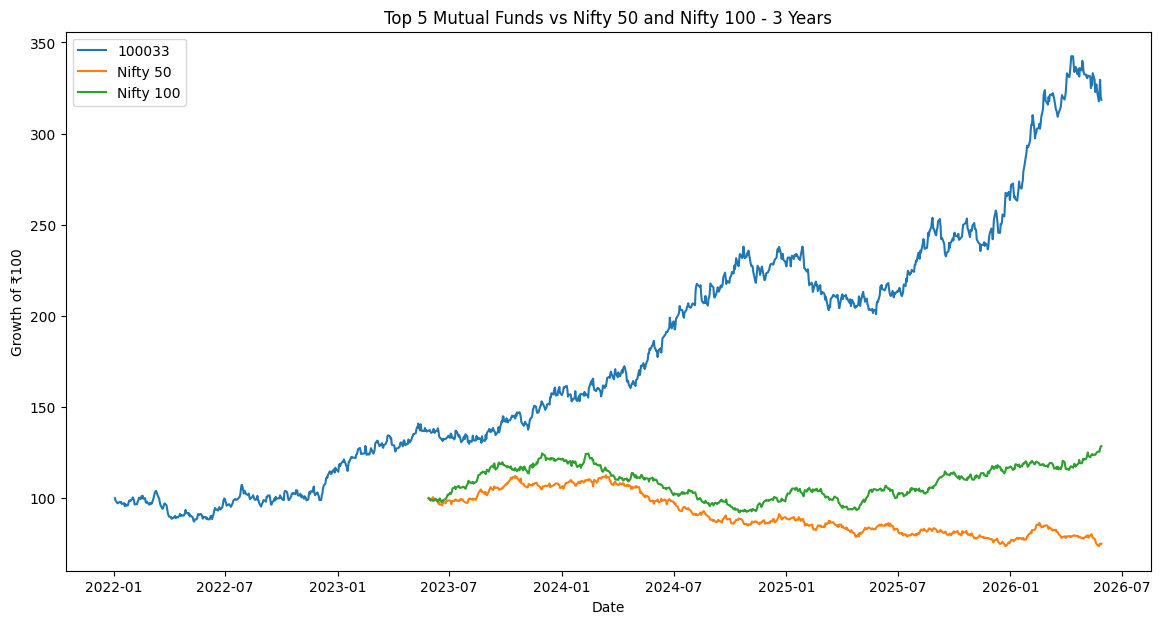

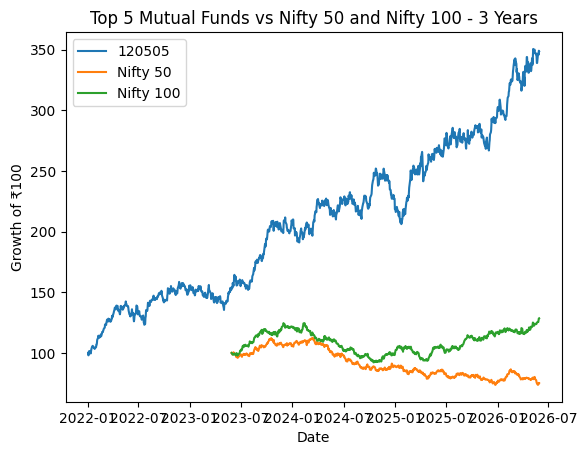

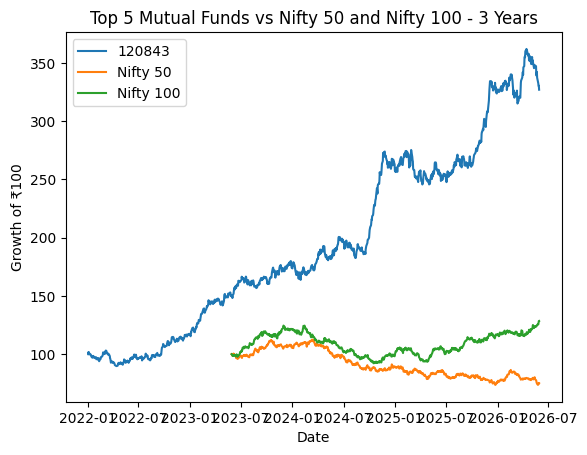

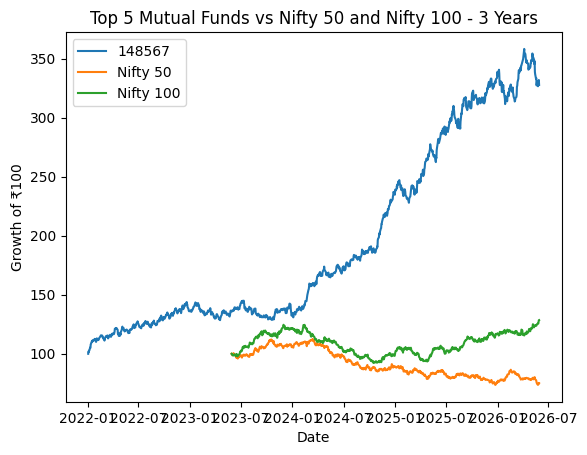

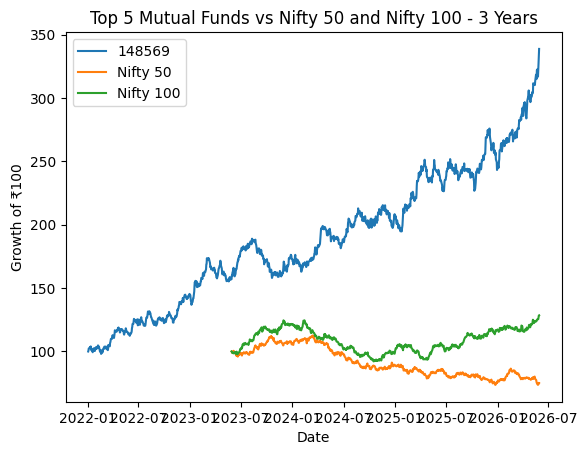

In [164]:
# benchmark chart
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
for amfi_code, group in fund_chart.groupby("amfi_code"):
    plt.plot(group["date"],group["normalized"],label=str(amfi_code))
    plt.plot(nifty50["date"],nifty50["normalized"],label="Nifty 50") #add nifty
    plt.plot(nifty100["date"],nifty100["normalized"],label="Nifty 100")
    plt.title("Top 5 Mutual Funds vs Nifty 50 and Nifty 100 - 3 Years")
    plt.xlabel("Date")
    plt.ylabel("Growth of ₹100")
    plt.legend()
    plt.savefig("benchmark_comparison.png",dpi=300,bbox_inches="tight")
    plt.show()

In [166]:
# Calculate Tracking Error
benchmark_returns = nifty100[["date", "return"]].rename(
    columns={"return": "benchmark_return"})

In [167]:
tracking_data = pd.merge(top5_nav[["amfi_code", "date", "daily_returns"]],benchmark_returns,on="date",how="inner")

In [168]:
tracking_data["return_difference"] = (tracking_data["daily_returns"]- tracking_data["benchmark_return"])

In [169]:
# Calculate tracking error for each fund
tracking_error = (tracking_data.groupby("amfi_code")["return_difference"].std()* np.sqrt(252))

In [170]:
tracking_error_df = tracking_error.reset_index()
tracking_error_df.columns = ["amfi_code","Tracking_Error"]

In [171]:
tracking_error_df

,amfi_code,Tracking_Error
0,100033,0.224976
1,120505,0.232661
2,120843,0.206540
3,148567,0.187974
4,148569,0.217062
